# **Dataset:https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data**

## **-preprocessing**

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!unzip  /content/test.csv.zip
!unzip /content/train.csv.zip

Archive:  /content/test.csv.zip
  inflating: test.csv                
Archive:  /content/train.csv.zip
  inflating: train.csv               


In [ ]:
test_df= pd.read_csv('/content/test.csv')
train_df=pd.read_csv('/content/train.csv')
train_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
SEED = 42
np.random.seed(SEED)

In [ ]:
def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = nltk.word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return " ".join(lemmatized_tokens)

print("\nPreprocessing text...")
train_df['processed_comment_text'] = train_df['comment_text'].apply(preprocess_text)
test_df['processed_comment_text'] = test_df['comment_text'].apply(preprocess_text)

print("\nPreprocessing complete!")
print("\nSample processed text:")
print(train_df[['comment_text', 'processed_comment_text']].head(3))

target_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


Preprocessing text...

Preprocessing complete!

Sample processed text:
                                        comment_text  \
0  Explanation\nWhy the edits made under my usern...   
1  D'aww! He matches this background colour I'm s...   
2  Hey man, I'm really not trying to edit war. It...   

                              processed_comment_text  
0  explanation edits made username hardcore metal...  
1  daww match background colour seemingly stuck t...  
2  hey man really trying edit war guy constantly ...  


# **-Data Exploration**


Class counts:
toxic          :  15294 ( 9.58%)
severe_toxic   :   1595 ( 1.00%)
obscene        :   8449 ( 5.29%)
threat         :    478 ( 0.30%)
insult         :   7877 ( 4.94%)
identity_hate  :   1405 ( 0.88%)

Any toxic: 16225 (10.17%)


/tmp/ipython-input-1391286753.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


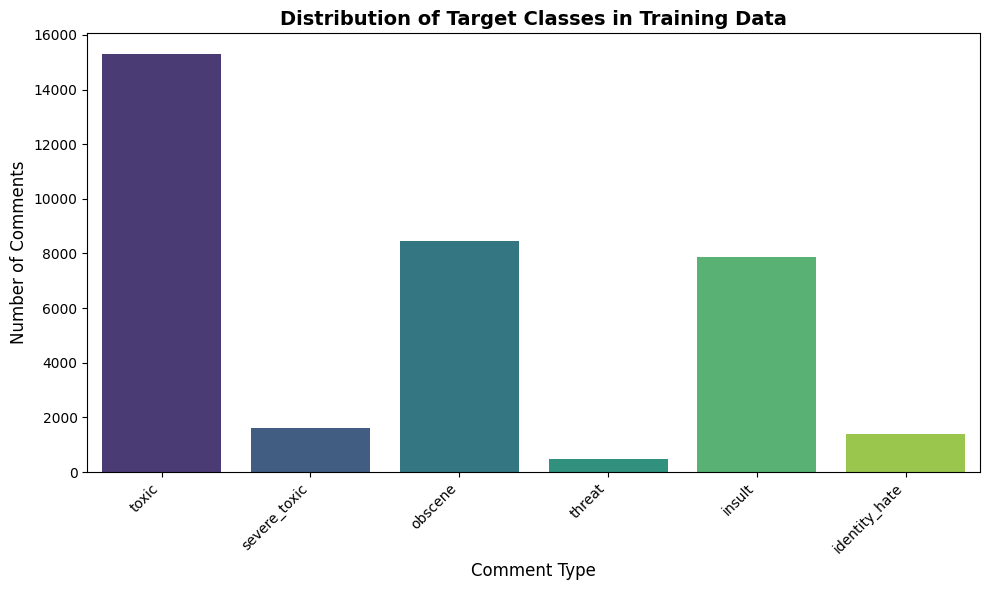

In [ ]:
class_counts = train_df[target_columns].sum()
class_percentages = (class_counts / len(train_df)) * 100

print("\nClass counts:")
for col in target_columns:
    print(f"{col:15s}: {class_counts[col]:6d} ({class_percentages[col]:5.2f}%)")

train_df['any_toxic'] = (train_df[target_columns].sum(axis=1) > 0).astype(int)
print(f"\nAny toxic: {train_df['any_toxic'].sum()} ({train_df['any_toxic'].mean()*100:.2f}%)")

plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Target Classes in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Comment Type', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=200)
plt.show()

In [ ]:
all_words = [word for comment in train_df['processed_comment_text'] for word in comment.split()]


**Word count statistics**


Word count statistics (train):
count    159571.000000
mean         33.916796
std          52.227941
min           0.000000
25%           8.000000
50%          18.000000
75%          37.000000
max        1250.000000
Name: word_count, dtype: float64


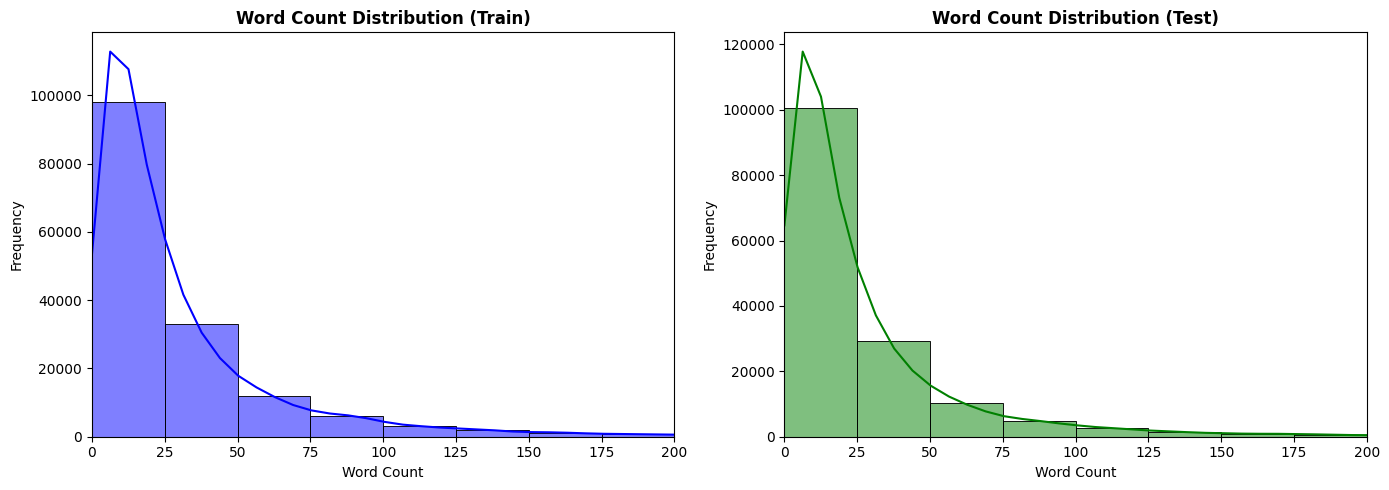

In [ ]:
train_df['word_count'] = train_df['processed_comment_text'].apply(lambda x: len(x.split()))
test_df['word_count'] = test_df['processed_comment_text'].apply(lambda x: len(x.split()))

print(f"\nWord count statistics (train):")
print(train_df['word_count'].describe())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['word_count'], bins=50, kde=True, color='blue')
plt.title('Word Count Distribution (Train)', fontsize=12, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 200)

plt.subplot(1, 2, 2)
sns.histplot(test_df['word_count'], bins=50, kde=True, color='green')
plt.title('Word Count Distribution (Test)', fontsize=12, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=200)
plt.show()


Top 30 most frequent words:
article        : 72910
page           : 56424
wikipedia      : 35619
talk           : 31233
one            : 29919
please         : 29605
would          : 29212
like           : 28128
dont           : 25735
see            : 21689


/tmp/ipython-input-2545380802.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word for word, _ in top_30_words], y=[count for _, count in top_30_words], palette='coolwarm')


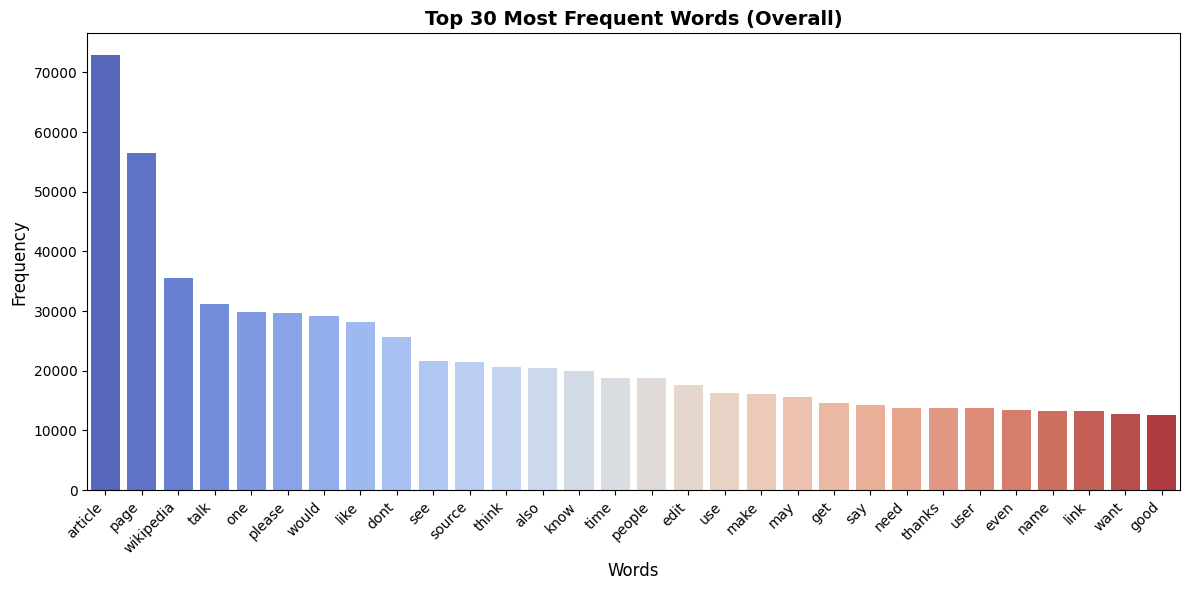

In [ ]:
word_counts = Counter(all_words)
top_30_words = word_counts.most_common(30)

print("\nTop 30 most frequent words:")
for word, count in top_30_words[:10]:
    print(f"{word:15s}: {count}")

plt.figure(figsize=(12, 6))
sns.barplot(x=[word for word, _ in top_30_words], y=[count for _, count in top_30_words], palette='coolwarm')
plt.title('Top 30 Most Frequent Words (Overall)', fontsize=14, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_words_overall.png', dpi=200)
plt.show()

# **-word representation methods**

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 91.8 MB/s eta 0:00:00


**TF-IDF**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import pickle


In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.8,
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(train_df['processed_comment_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['processed_comment_text'])

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print(f"TF-IDF matrix shape (train): {X_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")

TF-IDF matrix shape (train): (159571, 15000)
TF-IDF matrix shape (test): (153164, 15000)


**BERT (Sentence-BERT) Embedding Model**

In [ ]:
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding train data...")
bert_embeddings_train = bert_model.encode(
    train_df['processed_comment_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding test data...")
bert_embeddings_test = bert_model.encode(
    test_df['processed_comment_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

np.save("bert_embeddings_train.npy", bert_embeddings_train)
np.save("bert_embeddings_test.npy", bert_embeddings_test)

print(f"BERT embeddings shape (train): {bert_embeddings_train.shape}")
print(f"BERT embeddings shape (test): {bert_embeddings_test.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding train data...


Batches:   0%|          | 0/2494 [00:00<?, ?it/s]

Encoding test data...


Batches:   0%|          | 0/2394 [00:00<?, ?it/s]

BERT embeddings shape (train): (159571, 384)
BERT embeddings shape (test): (153164, 384)


**PCA + t-SNE on TF-IDF features**


Computing t-SNE for TF-IDF...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


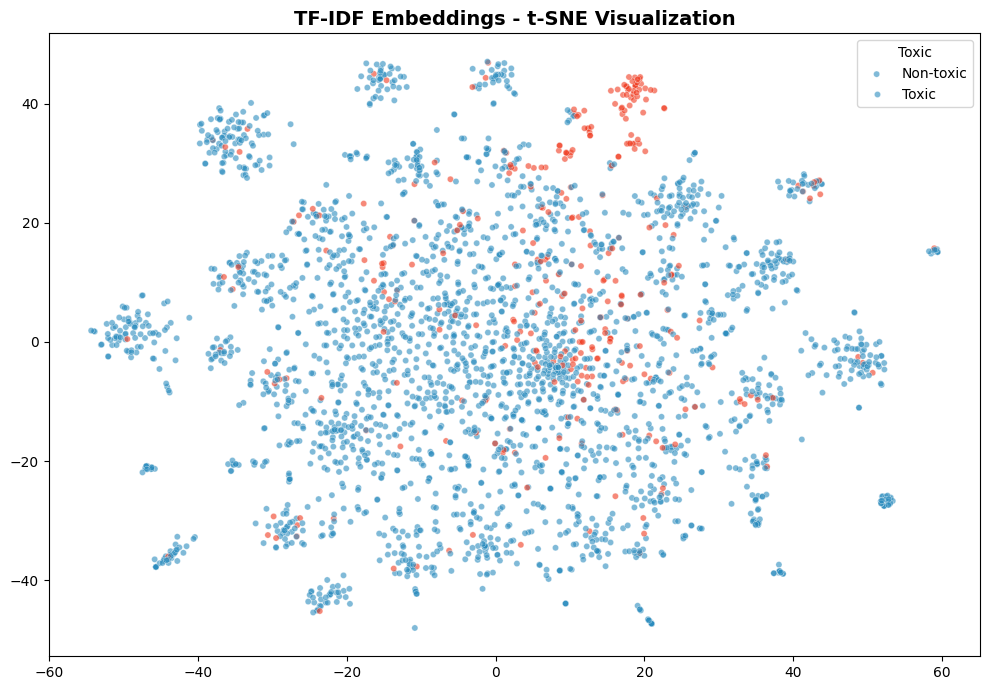

In [ ]:
SAMPLE_SIZE = 3000
sample_idx = np.random.choice(len(train_df), size=SAMPLE_SIZE, replace=False)

print("\nComputing t-SNE for TF-IDF...")
X_tfidf_sample = X_tfidf[sample_idx]
pca_tfidf = PCA(n_components=50, random_state=SEED)
X_tfidf_pca = pca_tfidf.fit_transform(X_tfidf_sample.toarray())

tsne_tfidf = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tfidf_tsne = tsne_tfidf.fit_transform(X_tfidf_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tfidf_tsne[:, 0],
    y=X_tfidf_tsne[:, 1],
    hue=train_df.iloc[sample_idx]['any_toxic'],
    palette={0: '#2b8cbe', 1: '#f03b20'},
    alpha=0.6,
    s=20
)
plt.title('TF-IDF Embeddings - t-SNE Visualization', fontsize=14, fontweight='bold')
plt.legend(labels=['Non-toxic', 'Toxic'])
plt.tight_layout()
plt.savefig('tfidf_tsne.png', dpi=200)
plt.show()


**PCA + t-SNE on Sentence-BERT embeddings**

Computing t-SNE for BERT...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


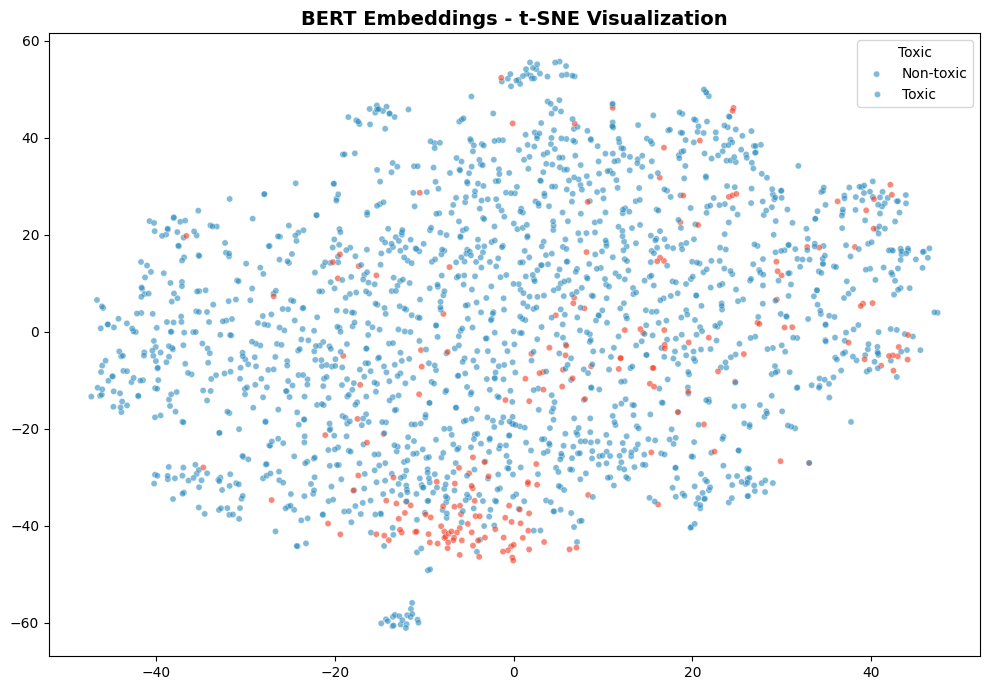

In [ ]:
print("Computing t-SNE for BERT...")
X_bert_sample = bert_embeddings_train[sample_idx]
pca_bert = PCA(n_components=50, random_state=SEED)
X_bert_pca = pca_bert.fit_transform(X_bert_sample)

tsne_bert = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_bert_tsne = tsne_bert.fit_transform(X_bert_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_bert_tsne[:, 0],
    y=X_bert_tsne[:, 1],
    hue=train_df.iloc[sample_idx]['any_toxic'],
    palette={0: '#2b8cbe', 1: '#f03b20'},
    alpha=0.6,
    s=20
)
plt.title('BERT Embeddings - t-SNE Visualization', fontsize=14, fontweight='bold')
plt.legend(title='Toxic', labels=['Non-toxic', 'Toxic'])
plt.tight_layout()
plt.savefig('bert_tsne.png', dpi=200)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

SAMPLE_SIZE = 2000
n_train = len(train_df)
np.random.seed(SEED)
sample_idx = np.random.RandomState(SEED).choice(n_train, SAMPLE_SIZE, replace=False)


if 'any_toxic' not in train_df.columns:
    train_df['any_toxic'] = 0
    target_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
    for c in target_cols:
        if c in train_df.columns:
            train_df['any_toxic'] = train_df['any_toxic'] | train_df[c]
sample_df = train_df.iloc[sample_idx]

labels = sample_df['any_toxic'].astype(int).values


X_tfidf_sample = X_tfidf[sample_idx]
pca_tfidf_silhouette = PCA(n_components=30, random_state=SEED)
X_pca_for_silhouette = pca_tfidf_silhouette.fit_transform(X_tfidf_sample.toarray())

X_sbert_sample = bert_embeddings_train[sample_idx]
pca_sbert_silhouette = PCA(n_components=30, random_state=SEED)
X_sbert_pca_for_silhouette = pca_sbert_silhouette.fit_transform(X_sbert_sample)

try:
    s_tfidf = silhouette_score(X_pca_for_silhouette, labels)
except Exception as e:
    s_tfidf = None
    print("Silhouette TF-IDF failed:", e)

try:
    s_sbert = silhouette_score(X_sbert_pca_for_silhouette, labels)
except Exception as e:
    s_sbert = None
    print("Silhouette SBERT failed:", e)

print("Silhouette score (TF-IDF PCA):", s_tfidf)
print("Silhouette score (SBERT PCA):", s_sbert)


Silhouette score (TF-IDF PCA): 0.023648375497021114
Silhouette score (SBERT PCA): 0.009661216


**Train / Validation Split + Tokenizer (LSTM)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

y = train_df[target_columns].values

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['any_toxic']
)

y_train = y[train_idx]
y_val = y[val_idx]

print(f"\nTrain size: {len(train_idx)}")
print(f"Validation size: {len(val_idx)}")
print(f"Toxic ratio in train: {train_df.iloc[train_idx]['any_toxic'].mean():.3f}")
print(f"Toxic ratio in val: {train_df.iloc[val_idx]['any_toxic'].mean():.3f}")


Train size: 127656
Validation size: 31915
Toxic ratio in train: 0.102
Toxic ratio in val: 0.102


**Model 1: TF-IDF + Logistic Regression (OvR)**

In [ ]:
X_train_tfidf = X_tfidf[train_idx]
X_val_tfidf = X_tfidf[val_idx]

lr_model = OneVsRestClassifier(
    LogisticRegression(
        C=4.0,
        max_iter=1000,
        solver='sag',
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    )
)

print("Training Logistic Regression...")
lr_model.fit(X_train_tfidf, y_train)

with open("lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Logistic Regression model trained and saved!")


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression model trained and saved!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    roc_auc_score,
    recall_score
)
y_val_pred_lr = lr_model.predict(X_val_tfidf)

try:
    y_val_proba_lr = lr_model.predict_proba(X_val_tfidf)
except Exception:
    y_val_proba_lr = None


print("\n=== Model 1: TF-IDF + Logistic Regression ===")
print("Classification report:")
print(classification_report(
    y_val,
    y_val_pred_lr,
    target_names=target_cols,
    zero_division=0
))


f1_micro_lr = f1_score(y_val, y_val_pred_lr, average='micro', zero_division=0)
f1_macro_lr = f1_score(y_val, y_val_pred_lr, average='macro', zero_division=0)

recall_micro_lr = recall_score(y_val, y_val_pred_lr, average='micro', zero_division=0)
recall_macro_lr = recall_score(y_val, y_val_pred_lr, average='macro', zero_division=0)

subset_acc_lr = accuracy_score(y_val, y_val_pred_lr)

print(f"Micro F1:        {f1_micro_lr:.4f}")
print(f"Subset Accuracy: {subset_acc_lr:.4f}")


if y_val_proba_lr is not None:
    try:
        auc_macro_lr = roc_auc_score(y_val, y_val_proba_lr, average='macro')
        print(f"Macro ROC-AUC:   {auc_macro_lr:.4f}")
    except Exception as e:
        print("ROC-AUC (TF-IDF + LR) failed:", e)



=== Model 1: TF-IDF + Logistic Regression ===
Classification report:
               precision    recall  f1-score   support

        toxic       0.62      0.83      0.71      3046
 severe_toxic       0.14      0.77      0.23       305
      obscene       0.55      0.86      0.67      1662
       threat       0.05      0.72      0.10        98
       insult       0.38      0.87      0.53      1576
identity_hate       0.09      0.77      0.16       259

    micro avg       0.37      0.84      0.52      6946
    macro avg       0.30      0.81      0.40      6946
 weighted avg       0.50      0.84      0.61      6946
  samples avg       0.05      0.08      0.06      6946

Micro F1:        0.5179
Macro F1:        0.4001
Micro Recall:    0.8413
Macro Recall:    0.8052
Subset Accuracy: 0.7894
Macro ROC-AUC:   0.9501


**Model 2: LSTM on token sequences**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 30000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['processed_comment_text'])

sequences = tokenizer.texts_to_sequences(train_df['processed_comment_text'])
X_seq = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = X_seq[train_idx]
X_val_seq = X_seq[val_idx]

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print(f"Vocabulary size: {min(MAX_WORDS, len(tokenizer.word_index) + 1)}")
print(f"Sequence shape: {X_train_seq.shape}")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBED_DIM = 256

class Attention(layers.Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

inputs = layers.Input(shape=(MAX_LEN,))
x = layers.Embedding(vocab_size, EMBED_DIM, input_length=MAX_LEN)(inputs)
x = layers.SpatialDropout1D(0.3)(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = Attention()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(target_columns), activation='sigmoid')(x)

lstm_model = models.Model(inputs=inputs, outputs=outputs)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

lstm_model.save("lstm_model.h5")
print("LSTM model trained and saved!")


Vocabulary size: 30000
Sequence shape: (127656, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 256)       │     7,680,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 256)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 200, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,272,390 (31.56 MB)

 Trainable params: 8,272,390 (31.56 MB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 91s 83ms/step - accuracy: 0.7172 - loss: 0.1304 - val_accuracy: 0.9938 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.9885 - loss: 0.0486 - val_accuracy: 0.9938 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.9892 - loss: 0.0429 - val_accuracy: 0.9938 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 4/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 79s 79ms/step - accuracy: 0.9701 - loss: 0.0372 - val_accuracy: 0.9938 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 78s 79ms/step - accuracy: 0.9049 - loss: 0.0319 - val_accuracy: 0.9937 - val_loss: 0.0610 - learning_rate: 5.0000e-04


LSTM model trained and saved!


In [ ]:
y_val_proba_lstm = lstm_model.predict(X_val_seq, batch_size=128)

THRESHOLD = 0.5
y_val_pred_lstm = (y_val_proba_lstm >= THRESHOLD).astype(int)

print("\n=== Model 2: BiLSTM + Attention ===")
print("Classification report:")
print(classification_report(
    y_val,
    y_val_pred_lstm,
    target_names=target_columns,
    zero_division=0
))

f1_micro_lstm = f1_score(y_val, y_val_pred_lstm, average='micro', zero_division=0)
f1_macro_lstm = f1_score(y_val, y_val_pred_lstm, average='macro', zero_division=0)

recall_micro_lstm = recall_score(y_val, y_val_pred_lstm, average='micro', zero_division=0)
recall_macro_lstm = recall_score(y_val, y_val_pred_lstm, average='macro', zero_division=0)

subset_acc_lstm = accuracy_score(y_val, y_val_pred_lstm)

print(f"Micro F1:        {f1_micro_lstm:.4f}")
print(f"Subset Accuracy: {subset_acc_lstm:.4f}")

try:
    auc_macro_lstm = roc_auc_score(y_val, y_val_proba_lstm, average='macro')
    print(f"Macro ROC-AUC:   {auc_macro_lstm:.4f}")
except Exception as e:
    print("ROC-AUC (LSTM) failed:", e)

250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step

=== Model 2: BiLSTM + Attention ===
Classification report:
               precision    recall  f1-score   support

        toxic       0.83      0.75      0.79      3046
 severe_toxic       0.48      0.36      0.41       305
      obscene       0.81      0.80      0.80      1662
       threat       0.00      0.00      0.00        98
       insult       0.72      0.71      0.72      1576
identity_hate       0.00      0.00      0.00       259

    micro avg       0.79      0.69      0.74      6946
    macro avg       0.47      0.43      0.45      6946
 weighted avg       0.74      0.69      0.72      6946
  samples avg       0.06      0.06      0.06      6946

Micro F1:        0.7380
Macro F1:        0.4528
Micro Recall:    0.6949
Macro Recall:    0.4349
Subset Accuracy: 0.9200
Macro ROC-AUC:   0.9720


**Model 3: Sentence-BERT Embeddings + MLP**

In [ ]:
X_train_bert = bert_embeddings_train[train_idx].astype('float32')
X_val_bert = bert_embeddings_train[val_idx].astype('float32')

n_features = X_train_bert.shape[1]

bert_mlp = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(target_columns), activation='sigmoid')
])

bert_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bert_mlp.summary()

print("\nTraining BERT+MLP model...")
history_bert = bert_mlp.fit(
    X_train_bert, y_train,
    validation_data=(X_val_bert, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

bert_mlp.save("bert_mlp_model.h5")
print("BERT+MLP model trained and saved!")

print("\n" + "="*80)
print("PHASE 1-2 COMPLETE!")
print("="*80)
print("\nAll models trained and saved:")
print("1. tfidf_vectorizer.pkl")
print("2. lr_model.pkl")
print("3. tokenizer.pkl")
print("4. lstm_model.h5")
print("5. bert_mlp_model.h5")
print("6. bert_embeddings_train.npy")
print("7. bert_embeddings_test.npy")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,190 (1.39 MB)

 Trainable params: 363,654 (1.39 MB)

 Non-trainable params: 1,536 (6.00 KB)


Training BERT+MLP model...
Epoch 1/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4883 - loss: 0.5131 - val_accuracy: 0.9625 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 2/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8103 - loss: 0.0916 - val_accuracy: 0.9736 - val_loss: 0.0917 - learning_rate: 0.0010
Epoch 3/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8764 - loss: 0.0886 - val_accuracy: 0.9899 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 4/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9268 - loss: 0.0854 - val_accuracy: 0.9196 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 5/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8933 - loss: 0.0827 - val_accuracy: 0.9925 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 6/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9526 - loss: 0.0807 - val_accuracy: 0.9935 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 7/15
998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accur

BERT+MLP model trained and saved!

PHASE 1-2 COMPLETE!

All models trained and saved:
1. tfidf_vectorizer.pkl
2. lr_model.pkl
3. tokenizer.pkl
4. lstm_model.h5
5. bert_mlp_model.h5
6. bert_embeddings_train.npy
7. bert_embeddings_test.npy


In [ ]:
y_val_proba_bert = bert_mlp.predict(X_val_bert, batch_size=128)

THRESHOLD = 0.5
y_val_pred_bert = (y_val_proba_bert >= THRESHOLD).astype(int)

print("\n=== Model 3: BERT Embeddings + MLP ===")
print("Classification report:")
print(classification_report(
    y_val,
    y_val_pred_bert,
    target_names=target_columns,
    zero_division=0
))

f1_micro_bert = f1_score(y_val, y_val_pred_bert, average='micro', zero_division=0)
f1_macro_bert = f1_score(y_val, y_val_pred_bert, average='macro', zero_division=0)

recall_micro_bert = recall_score(y_val, y_val_pred_bert, average='micro', zero_division=0)
recall_macro_bert = recall_score(y_val, y_val_pred_bert, average='macro', zero_division=0)

subset_acc_bert = accuracy_score(y_val, y_val_pred_bert)

print(f"Micro F1:        {f1_micro_bert:.4f}")
print(f"Subset Accuracy: {subset_acc_bert:.4f}")

try:
    auc_macro_bert = roc_auc_score(y_val, y_val_proba_bert, average='macro')
    print(f"Macro ROC-AUC:   {auc_macro_bert:.4f}")
except Exception as e:
    print("ROC-AUC (BERT + MLP) failed:", e)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

=== Model 3: BERT Embeddings + MLP ===
Classification report:
               precision    recall  f1-score   support

        toxic       0.82      0.62      0.70      3046
 severe_toxic       0.57      0.09      0.15       305
      obscene       0.77      0.70      0.73      1662
       threat       0.80      0.04      0.08        98
       insult       0.74      0.61      0.67      1576
identity_hate       0.76      0.16      0.26       259

    micro avg       0.78      0.59      0.67      6946
    macro avg       0.74      0.37      0.43      6946
 weighted avg       0.77      0.59      0.65      6946
  samples avg       0.05      0.05      0.05      6946

Micro F1:        0.6698
Macro F1:        0.4319
Micro Recall:    0.5864
Macro Recall:    0.3685
Subset Accuracy: 0.9124
Macro ROC-AUC:   0.9702


In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BiLSTM + Attention",
        "SBERT Embeddings + MLP"
    ],
    "Micro F1": [
        f1_micro_lr,
        f1_micro_lstm,
        f1_micro_bert
    ],
    "Micro Recall": [
        recall_micro_lr,
        recall_micro_lstm,
        recall_micro_bert
    ],
    "Macro Recall": [
        recall_macro_lr,
        recall_macro_lstm,
        recall_macro_bert
    ],
    "Subset Accuracy": [
        subset_acc_lr,
        subset_acc_lstm,
        subset_acc_bert
    ],
    "Macro ROC-AUC": [
        auc_macro_lr,
        auc_macro_lstm,
        auc_macro_bert
    ]
})

display(results_df)


,Model,Micro F1,Macro F1,Micro Recall,Macro Recall,Subset Accuracy,Macro ROC-AUC
0,TF-IDF + Logistic Regression,0.517856,0.400109,0.841348,0.805183,0.789378,0.950131
1,BiLSTM + Attention,0.737961,0.452849,0.694932,0.434908,0.919975,0.972024
2,SBERT Embeddings + MLP,0.669846,0.431886,0.586381,0.368452,0.912424,0.970215


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        output = x * a
        return tf.reduce_sum(output, axis=1)

lstm_model = tf.keras.models.load_model("lstm_model.h5", custom_objects={'Attention': Attention})

bert_mlp = tf.keras.models.load_model("bert_mlp_model.h5")

bert_embeddings_train = np.load("bert_embeddings_train.npy")

print("All models loaded successfully!")


All models loaded successfully!


**Prepare data splits (same as training)**

In [ ]:
from sklearn.model_selection import train_test_split

y = train_df[target_columns].values
train_df['any_toxic'] = (train_df[target_columns].sum(axis=1) > 0).astype(int)

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['any_toxic']
)

y_train = y[train_idx]
y_val = y[val_idx]

print(f"\nValidation set size: {len(val_idx)}")


Validation set size: 31915


**MAKE PREDICTIONS**

In [ ]:
print("\n1. Logistic Regression predictions...")
y_pred_lr = lr_model.predict(X_val_tfidf)
y_proba_lr = lr_model.predict_proba(X_val_tfidf)

print("2. LSTM predictions...")
y_proba_lstm = lstm_model.predict(X_val_seq, batch_size=256, verbose=0)
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

print("3. BERT+MLP predictions...")
y_proba_bert = bert_mlp.predict(X_val_bert, batch_size=256, verbose=0)
y_pred_bert = (y_proba_bert >= 0.5).astype(int)


1. Logistic Regression predictions...
2. LSTM predictions...
3. BERT+MLP predictions...


**CALCULATE METRICS**

In [ ]:
from sklearn.metrics import (f1_score, accuracy_score, roc_auc_score, hamming_loss)
import numpy as np

def calculate_metrics(y_true, y_pred, y_proba, model_name):
    """Calculate comprehensive metrics"""
    results = {}

    results['micro_f1'] = f1_score(y_true, y_pred, average='micro', zero_division=0)
    results['weighted_f1'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results['subset_accuracy'] = accuracy_score(y_true, y_pred)

    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    for i, col in enumerate(target_columns):
        results[f'f1_{col}'] = per_class_f1[i]

    try:
        results['macro_auc'] = roc_auc_score(y_true, y_proba, average='macro')
        results['weighted_auc'] = roc_auc_score(y_true, y_proba, average='weighted')
    except Exception as e:
        print(f"Warning: Could not calculate AUC for {model_name}: {e}")
        results['macro_auc'] = np.nan
        results['weighted_auc'] = np.nan

    return results

metrics_lr = calculate_metrics(y_val, y_pred_lr, y_proba_lr, "Logistic Regression")
metrics_lstm = calculate_metrics(y_val, y_pred_lstm, y_proba_lstm, "LSTM")
metrics_bert = calculate_metrics(y_val, y_pred_bert, y_proba_bert, "BERT+MLP")


**Create comparison dataframe**

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'BiLSTM + Attention', 'BERT + MLP'],
    'Micro F1': [metrics_lr['micro_f1'], metrics_lstm['micro_f1'], metrics_bert['micro_f1']],
    'Weighted F1': [metrics_lr['weighted_f1'], metrics_lstm['weighted_f1'], metrics_bert['weighted_f1']],
    'Subset Accuracy': [metrics_lr['subset_accuracy'], metrics_lstm['subset_accuracy'], metrics_bert['subset_accuracy']],
    'Macro AUC': [metrics_lr['macro_auc'], metrics_lstm['macro_auc'], metrics_bert['macro_auc']],
    'Weighted AUC': [metrics_lr['weighted_auc'], metrics_lstm['weighted_auc'], metrics_bert['weighted_auc']]
})

print("\n", comparison_df.to_string(index=False))

comparison_df.to_csv('model_comparison_results.csv', index=False)


               Model  Micro F1  Macro F1  Weighted F1  Subset Accuracy  Hamming Loss  Macro AUC  Weighted AUC
Logistic Regression  0.517856  0.400109     0.609919         0.789378      0.056828   0.950131      0.961047
 BiLSTM + Attention  0.737961  0.452849     0.718395         0.919975      0.017902   0.972024      0.978642
         BERT + MLP  0.669846  0.431886     0.652582         0.912424      0.020967   0.970215      0.966039


**1. Overall metrics comparison**

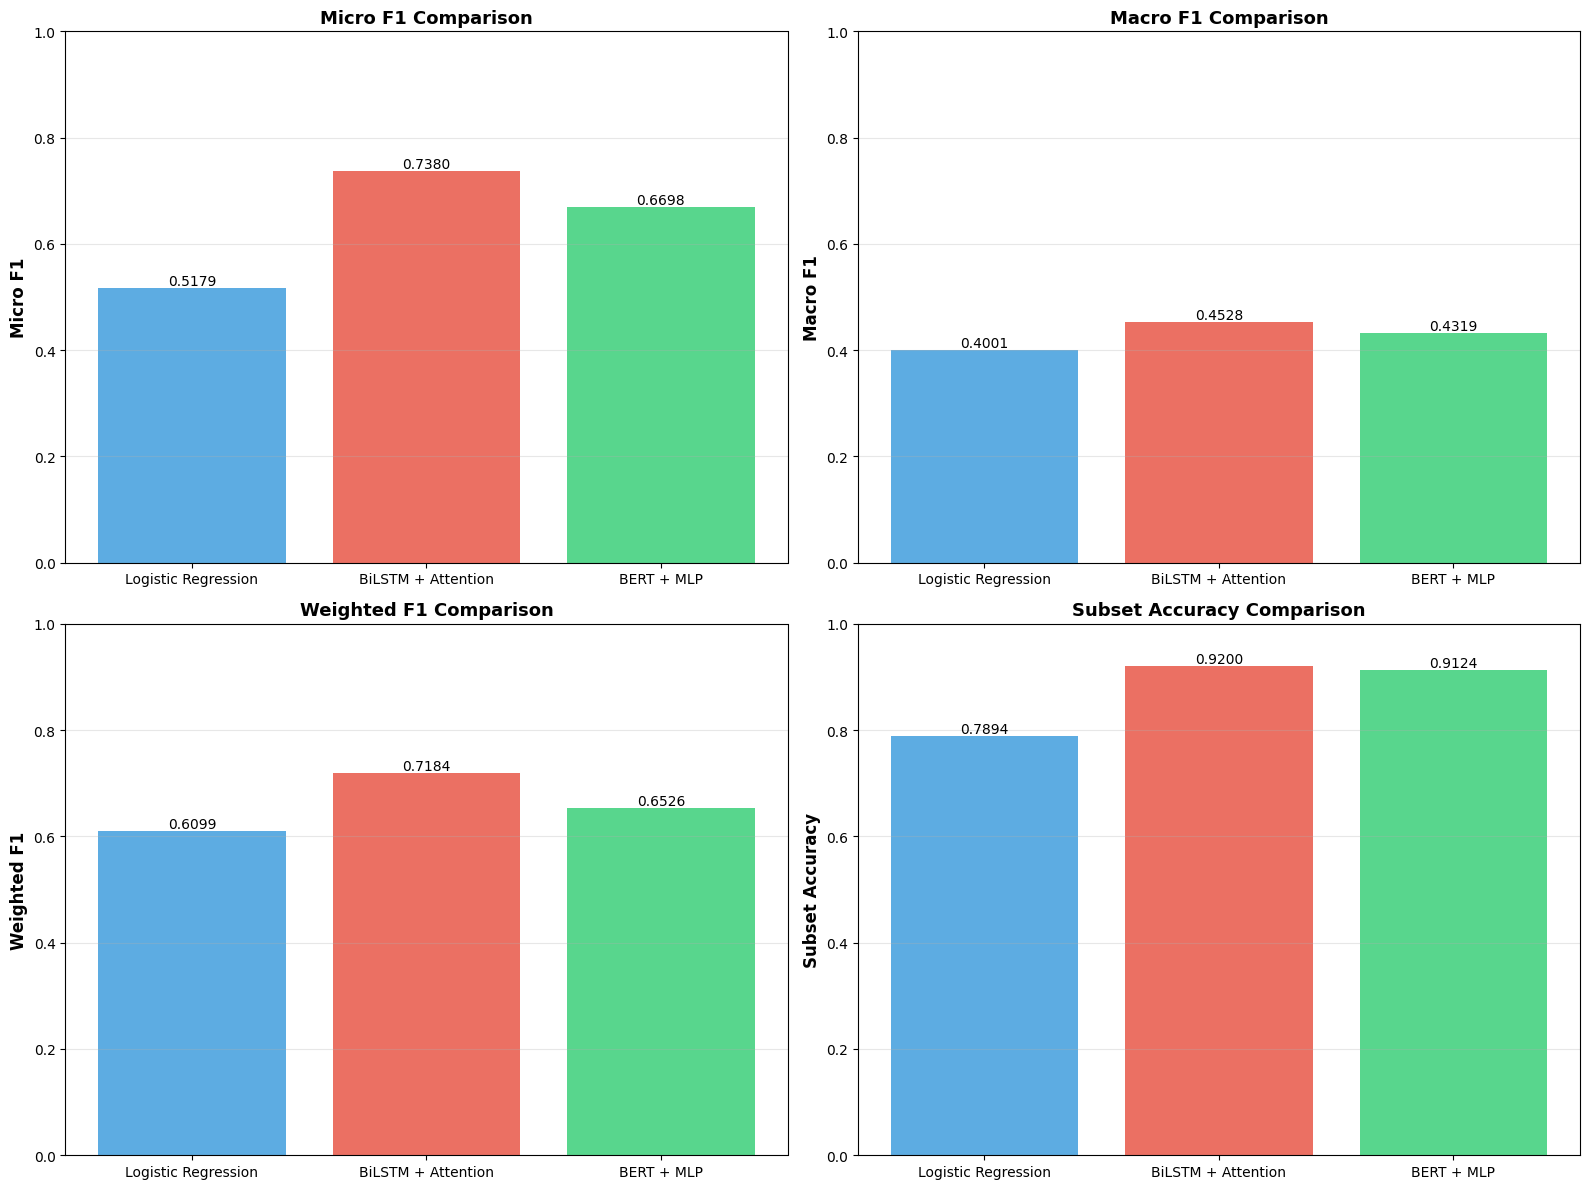

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Micro F1', 'Macro F1', 'Weighted F1', 'Subset Accuracy']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Model'], values, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('overall_metrics_comparison.png', dpi=200)
plt.show()

**2. Per-class F1 scores**

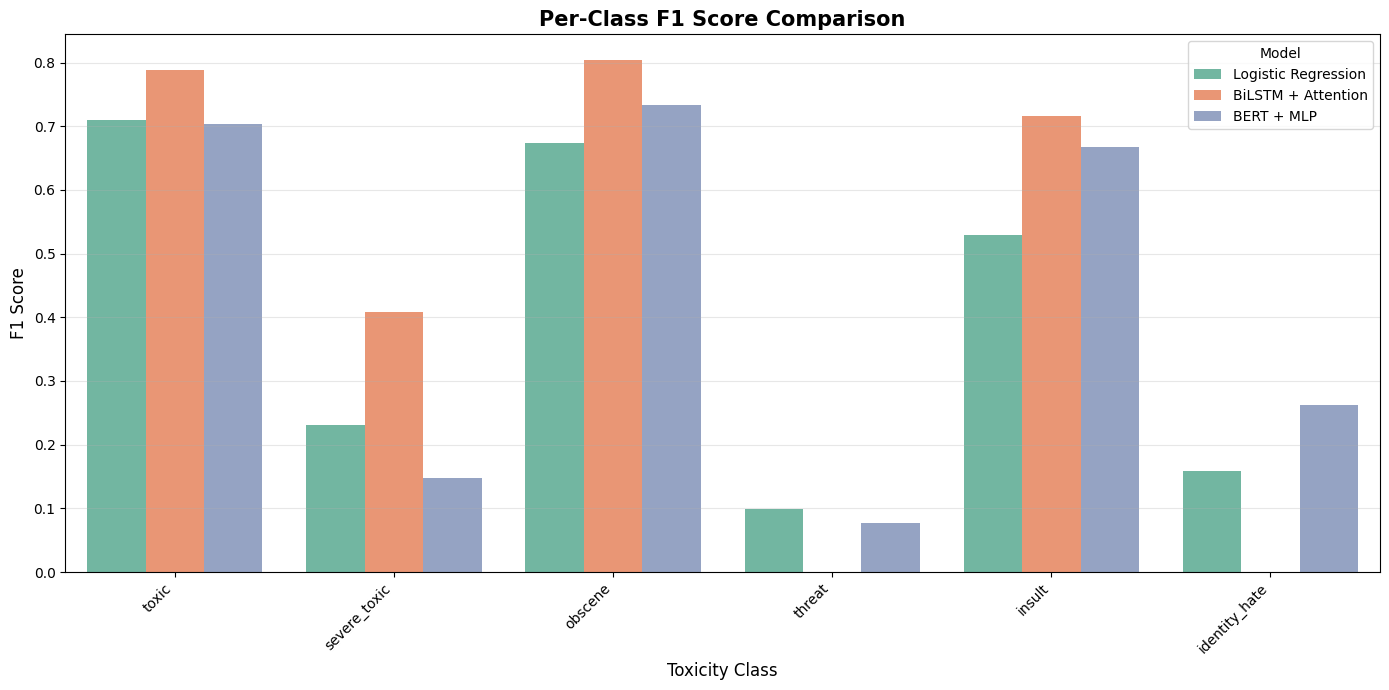

In [ ]:
per_class_data = {
    'Class': target_columns * 3,
    'Model': ['Logistic Regression'] * 6 + ['BiLSTM + Attention'] * 6 + ['BERT + MLP'] * 6,
    'F1 Score': []
}

for col in target_columns:
    per_class_data['F1 Score'].append(metrics_lr[f'f1_{col}'])
for col in target_columns:
    per_class_data['F1 Score'].append(metrics_lstm[f'f1_{col}'])
for col in target_columns:
    per_class_data['F1 Score'].append(metrics_bert[f'f1_{col}'])

per_class_df = pd.DataFrame(per_class_data)

plt.figure(figsize=(14, 7))
sns.barplot(data=per_class_df, x='Class', y='F1 Score', hue='Model', palette='Set2')
plt.title('Per-Class F1 Score Comparison', fontsize=15, fontweight='bold')
plt.xlabel('Toxicity Class', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=200)
plt.show()

**3. Classification reports**


Logistic Regression
               precision    recall  f1-score   support

        toxic       0.62      0.83      0.71      3046
 severe_toxic       0.14      0.77      0.23       305
      obscene       0.55      0.86      0.67      1662
       threat       0.05      0.72      0.10        98
       insult       0.38      0.87      0.53      1576
identity_hate       0.09      0.77      0.16       259

    micro avg       0.37      0.84      0.52      6946
    macro avg       0.30      0.81      0.40      6946
 weighted avg       0.50      0.84      0.61      6946
  samples avg       0.05      0.08      0.06      6946


BiLSTM + Attention
               precision    recall  f1-score   support

        toxic       0.83      0.75      0.79      3046
 severe_toxic       0.48      0.36      0.41       305
      obscene       0.81      0.80      0.80      1662
       threat       0.00      0.00      0.00        98
       insult       0.72      0.71      0.72      1576
identity_hate       

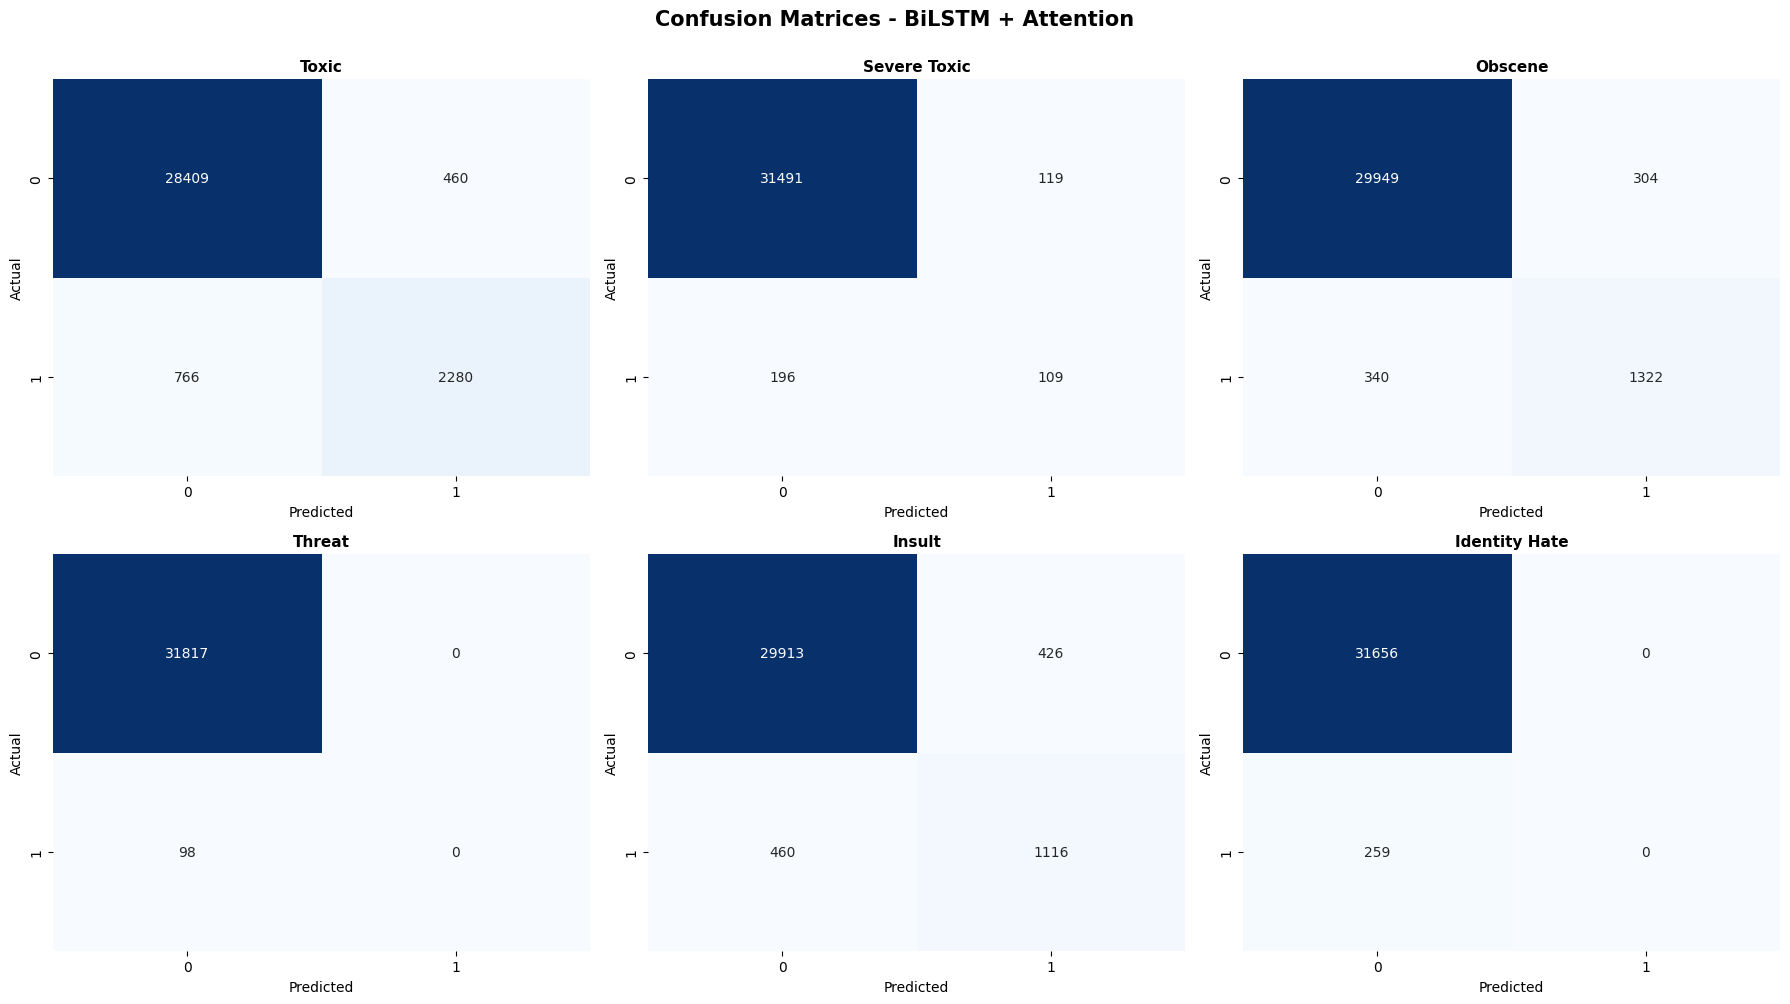

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

models = [
    ("Logistic Regression", y_pred_lr),
    ("BiLSTM + Attention", y_pred_lstm),
    ("BERT + MLP", y_pred_bert)
]

for model_name, y_pred in models:
    print(f"\n{'='*80}")
    print(f"{model_name}")
    print('='*80)
    print(classification_report(y_val, y_pred, target_names=target_columns, zero_division=0))

best_model_idx = comparison_df['Macro F1'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_preds = [y_pred_lr, y_pred_lstm, y_pred_bert][best_model_idx]

print(f"\n\nBest model: {best_model_name} (Macro F1: {comparison_df.loc[best_model_idx, 'Macro F1']:.4f})")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(target_columns):
    cm = confusion_matrix(y_val[:, idx], best_model_preds[:, idx])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{col.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle(f'Confusion Matrices - {best_model_name}', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices_best_model.png', dpi=200)
plt.show()

**4. ROC curves for best model**

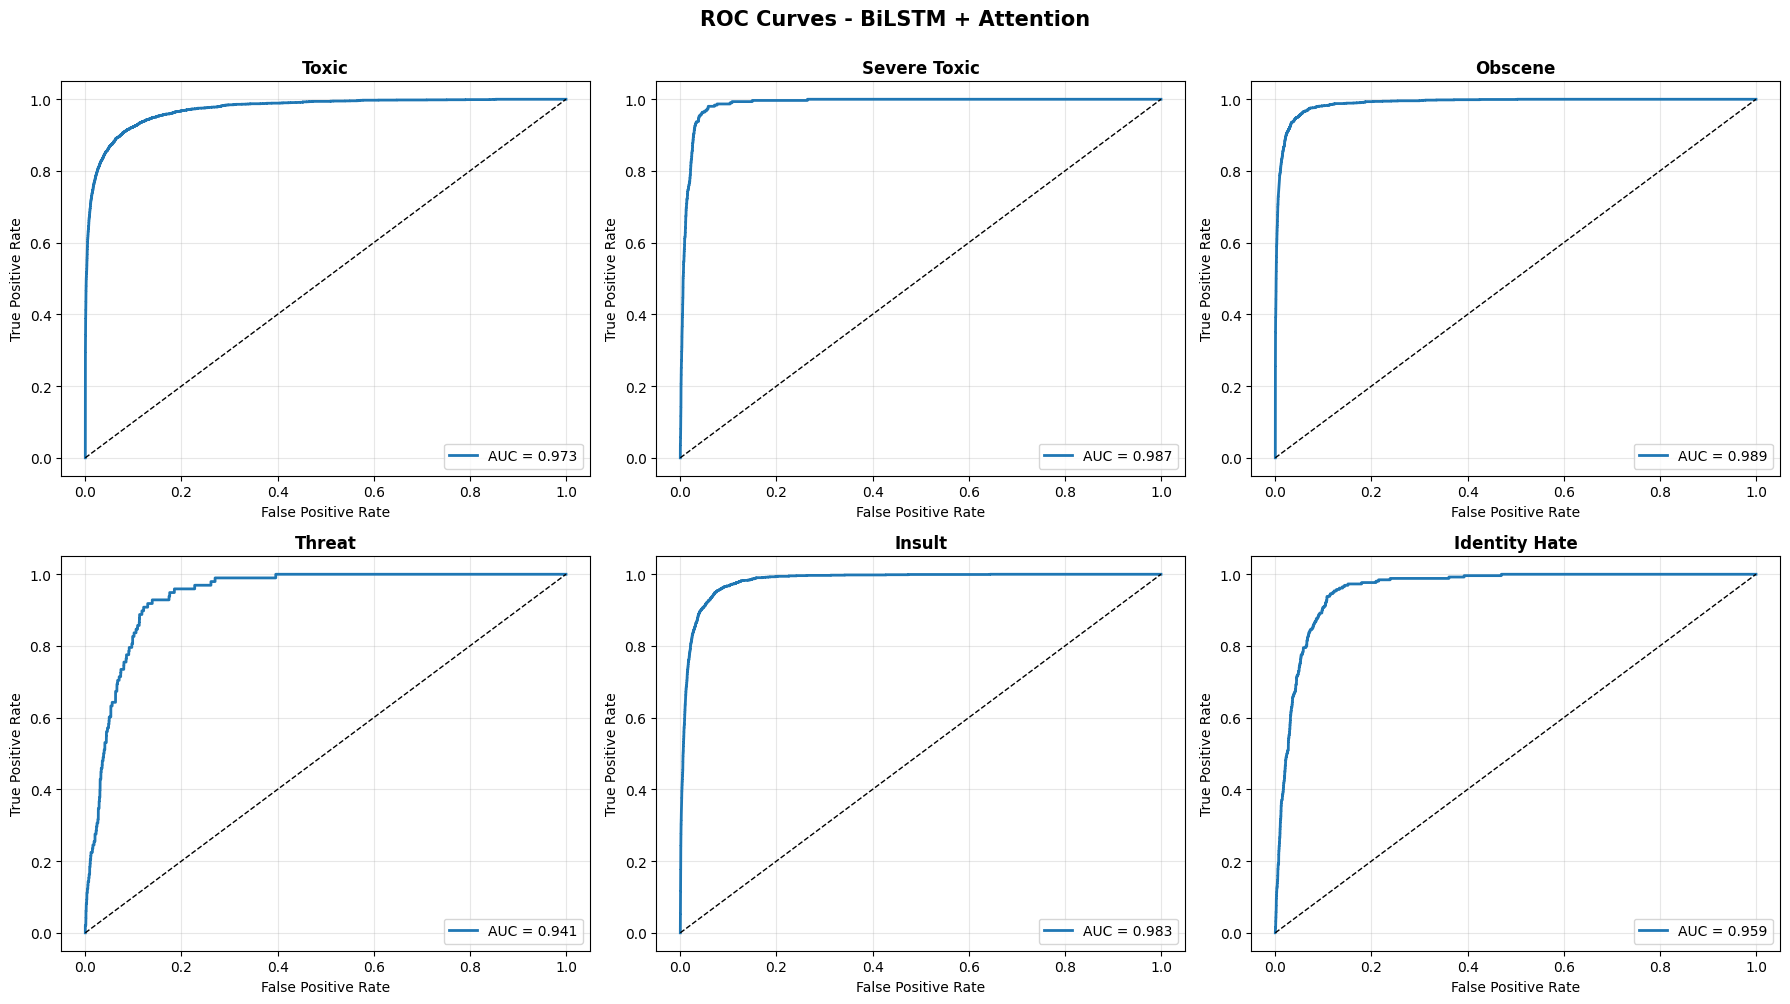

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

best_model_proba = [y_proba_lr, y_proba_lstm, y_proba_bert][best_model_idx]

for idx, col in enumerate(target_columns):
    fpr, tpr, _ = roc_curve(y_val[:, idx], best_model_proba[:, idx])
    auc_score = roc_auc_score(y_val[:, idx], best_model_proba[:, idx])

    axes[idx].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.3f}')
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    axes[idx].legend(loc='lower right')
    axes[idx].grid(alpha=0.3)

plt.suptitle(f'ROC Curves - {best_model_name}', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('roc_curves_best_model.png', dpi=200)
plt.show()